<a href="https://colab.research.google.com/github/Aftabal1m/Aftabal1m/blob/main/Titanic%20Survival%20Prediction%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# prompt: want to connect with the google drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Co

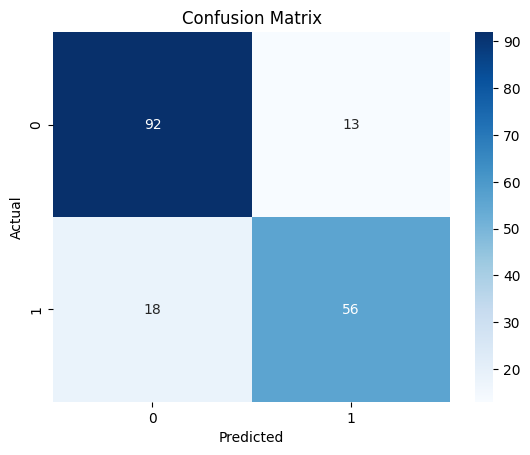

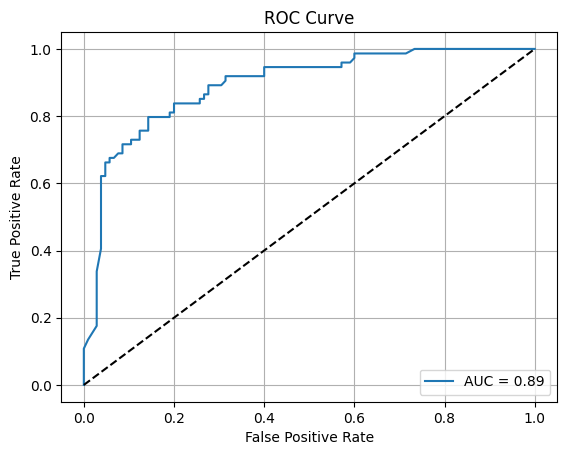

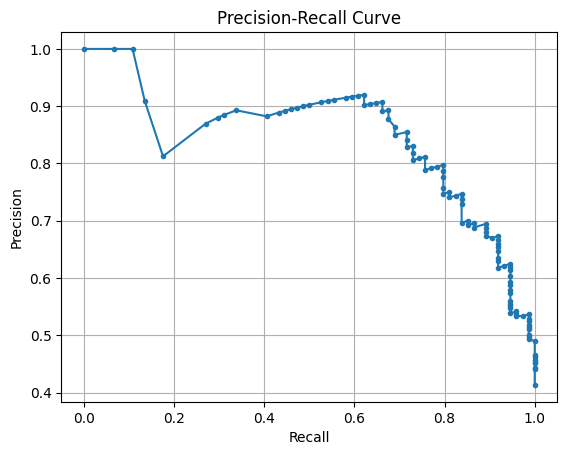

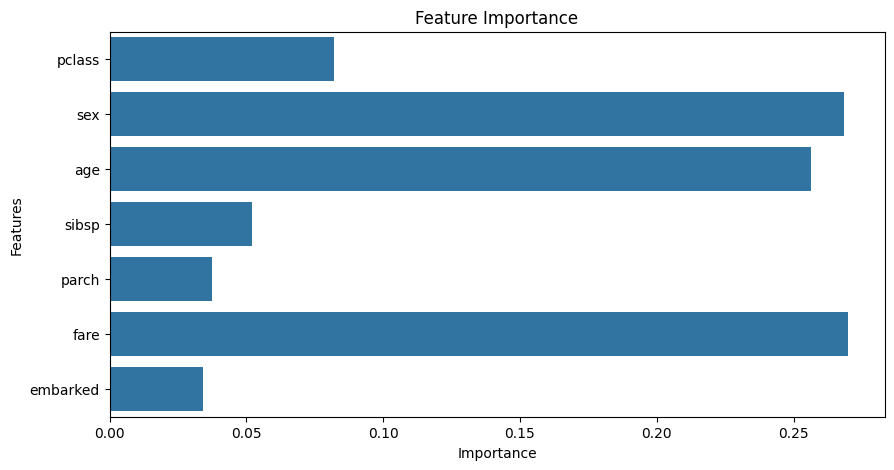

In [3]:
# Importing required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Titanic-Dataset.csv")
print(df.head())

# Preview column names
print("Columns in dataset:", df.columns.tolist())

# Rename columns to lowercase for consistency (optional)
df.columns = [col.lower() for col in df.columns]

# Drop columns only if they exist
drop_cols = ['deck', 'embark_town', 'alive', 'who', 'class']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

# Fill missing values
if 'age' in df.columns:
    df['age'] = df['age'].fillna(df['age'].median())
if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encode categorical variables
if 'sex' in df.columns:
    df['sex'] = df['sex'].map({'male': 0, 'female': 1})
if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})
if 'alone' in df.columns:
    df['alone'] = df['alone'].astype(int)

# Define features and target
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
if 'alone' in df.columns:
    features.append('alone')

X = df[features]
y = df['survived']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Accuracy & Classification Report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

# Feature Importance
importances = model.feature_importances_
feat_names = X.columns
plt.figure(figsize=(10, 5))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:56:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.8212290502793296

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



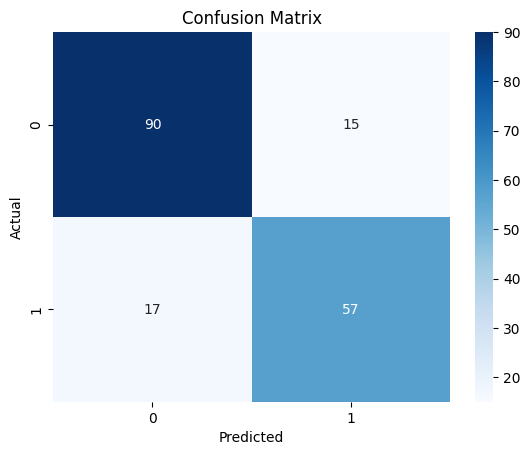

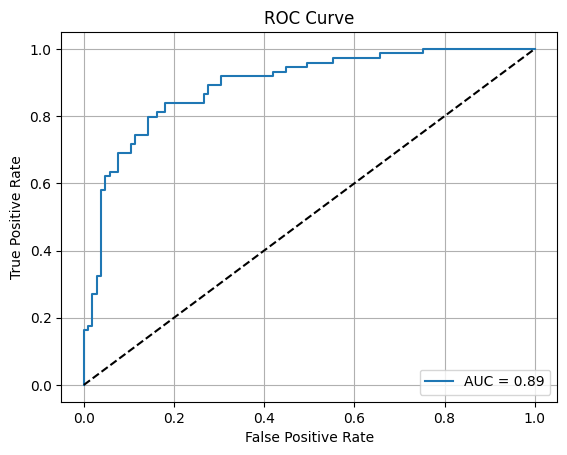

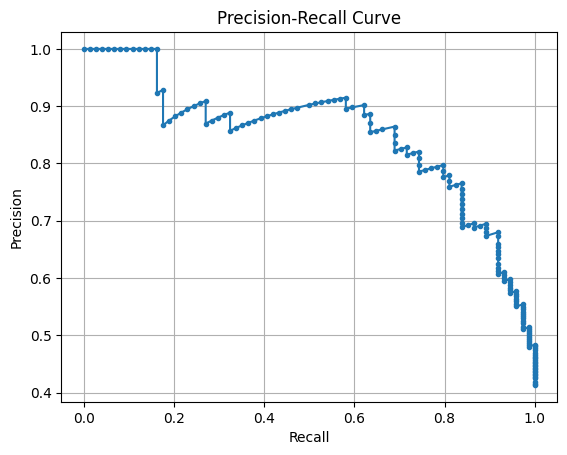

<Figure size 1000x500 with 0 Axes>

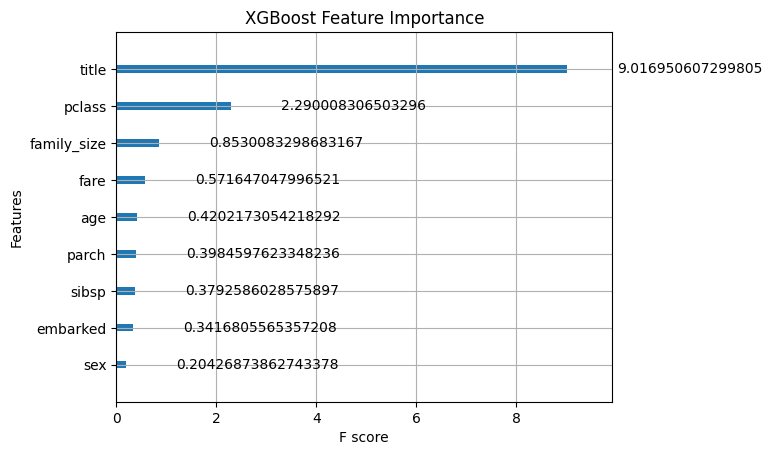

In [4]:
# Importing required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Titanic-Dataset.csv")

# Standardize column names
df.columns = [col.lower() for col in df.columns]

# Handle missing values
if 'age' in df.columns:
    df['age'] = df['age'].fillna(df['age'].median())
if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encode categorical variables
if 'sex' in df.columns:
    df['sex'] = df['sex'].map({'male': 0, 'female': 1})
if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Optional: Create new features
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['title'] = df['name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['title'] = df['title'].replace(['Mlle', 'Ms', 'Lady', 'Dona'], 'Miss')
df['title'] = df['title'].replace(['Mme', 'Countess'], 'Mrs')
df['title'] = df['title'].replace(['Capt', 'Col', 'Major', 'Dr', 'Rev', 'Jonkheer', 'Don', 'Sir'], 'Rare')
df['title'] = df['title'].map({'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5})
df['title'] = df['title'].fillna(0)

# Define features and target
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'title']
X = df[features]
y = df['survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train XGBoost model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

# Feature Importance
plt.figure(figsize=(10, 5))
xgb.plot_importance(xgb_model, importance_type='gain', title='XGBoost Feature Importance')
plt.show()


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:59:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Ensemble Model Accuracy: 0.8324022346368715

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179



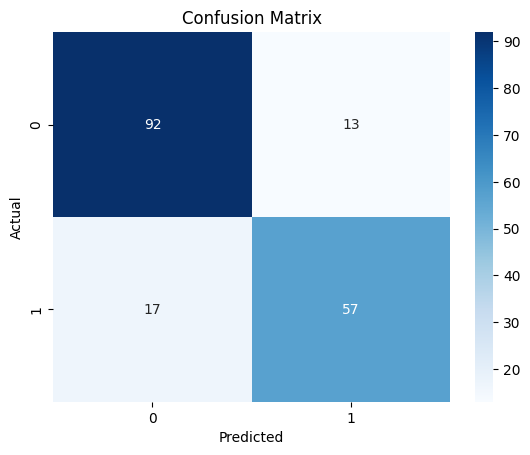

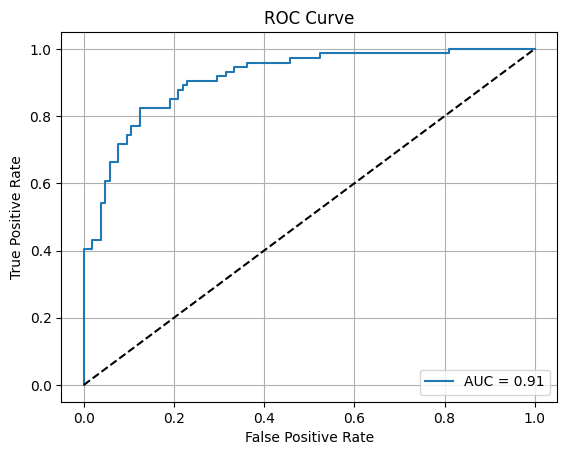

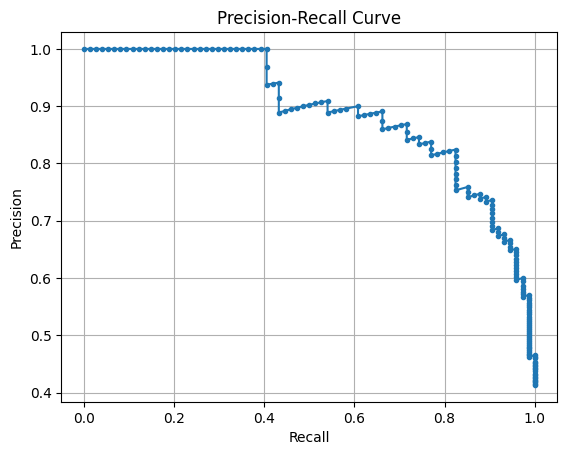

In [5]:
# Required Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score, precision_recall_curve
)
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Titanic-Dataset.csv")
df.columns = [col.lower() for col in df.columns]

# Fill missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encode categorical
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Feature engineering
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['title'] = df['name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['title'] = df['title'].replace(['Mlle', 'Ms', 'Lady', 'Dona'], 'Miss')
df['title'] = df['title'].replace(['Mme', 'Countess'], 'Mrs')
df['title'] = df['title'].replace(['Capt', 'Col', 'Major', 'Dr', 'Rev', 'Jonkheer', 'Don', 'Sir'], 'Rare')
df['title'] = df['title'].map({'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5})
df['title'] = df['title'].fillna(0)

# Select features and target
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'title']
X = df[features]
y = df['survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models
rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
log_model = LogisticRegression(max_iter=1000)

# Combine into voting classifier (soft voting for proba averaging)
voting_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('logreg', log_model)
    ],
    voting='soft'  # Change to 'hard' for class label voting
)

# Train ensemble
voting_model.fit(X_train, y_train)

# Predictions
y_pred = voting_model.predict(X_test)
y_proba = voting_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Ensemble Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()



🎯 XGBoost Accuracy: 0.8212


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [11:03:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


🗳️ Voting Classifier Accuracy: 0.8324

✅ Best Performing Model: Voting Classifier

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.77      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.83      0.83      0.83       179



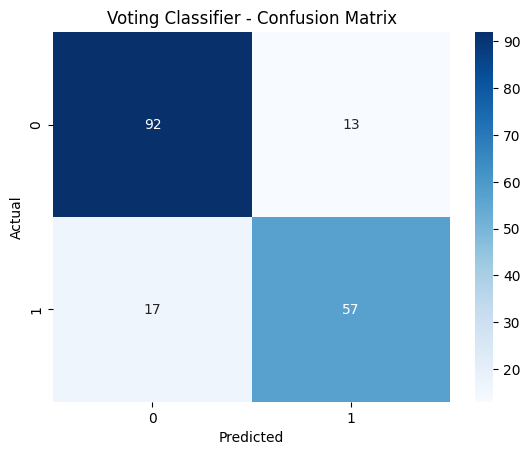

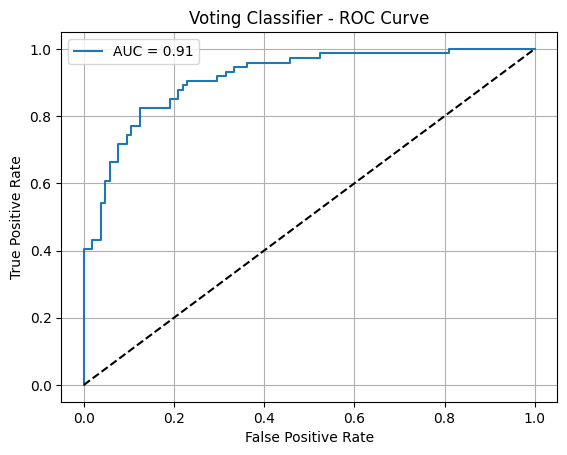

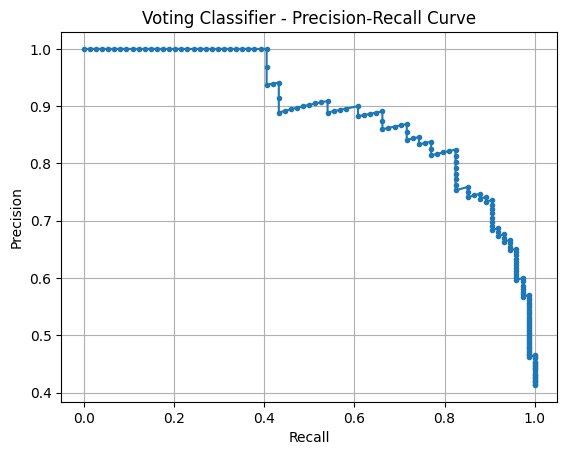

In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score, precision_recall_curve
)

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Titanic-Dataset.csv")
df.columns = [col.lower() for col in df.columns]

# Fill missing values
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encode categorical features
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Feature Engineering
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['title'] = df['name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['title'] = df['title'].replace(['Mlle', 'Ms', 'Lady', 'Dona'], 'Miss')
df['title'] = df['title'].replace(['Mme', 'Countess'], 'Mrs')
df['title'] = df['title'].replace(['Capt', 'Col', 'Major', 'Dr', 'Rev', 'Jonkheer', 'Don', 'Sir'], 'Rare')
df['title'] = df['title'].map({'Mr': 1, 'Miss': 2, 'Mrs': 3, 'Master': 4, 'Rare': 5})
df['title'] = df['title'].fillna(0)

# Feature and target selection
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size', 'title']
X = df[features]
y = df['survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Model 1: XGBoost ---
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"\n🎯 XGBoost Accuracy: {xgb_acc:.4f}")

# --- Model 2: VotingClassifier with XGB, RF, and Logistic Regression ---
rf_model = RandomForestClassifier(n_estimators=150, random_state=42)
log_model = LogisticRegression(max_iter=1000)
voting_model = VotingClassifier(
    estimators=[('xgb', xgb_model), ('rf', rf_model), ('log', log_model)],
    voting='soft'
)
voting_model.fit(X_train, y_train)
voting_pred = voting_model.predict(X_test)
voting_proba = voting_model.predict_proba(X_test)[:, 1]
voting_acc = accuracy_score(y_test, voting_pred)
print(f"🗳️ Voting Classifier Accuracy: {voting_acc:.4f}")

# --- Evaluation: Best performing model ---
best_pred = voting_pred if voting_acc > xgb_acc else xgb_pred
best_proba = voting_proba if voting_acc > xgb_acc else xgb_proba
model_name = "Voting Classifier" if voting_acc > xgb_acc else "XGBoost"

print(f"\n✅ Best Performing Model: {model_name}\n")
print("Classification Report:\n", classification_report(y_test, best_pred))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"{model_name} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, best_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, best_proba):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"{model_name} - ROC Curve")
plt.legend()
plt.grid()
plt.show()

# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, best_proba)
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"{model_name} - Precision-Recall Curve")
plt.grid()
plt.show()
